In [45]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    roc_auc_score,
    f1_score,
    recall_score,
    roc_curve,
    classification_report,
    precision_recall_curve
)

import joblib

In [2]:
DATA_PATH = "../Data/Preprocessed_data.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLD = 5

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,person_age,person_income,person_monthly_income,person_emp_length,emp_stability,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,person_home_ownership_OTHER,credit_hist_ratio,debt_burden_index,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,3.091042,9.169623,6.685861,1.791759,0.215111,1,6.908755,2.496506,0,0.095310,...,0,0.10,0.113329,1,0,1,0,0,0,0
1,3.258097,9.169623,6.685861,0.693147,0.039221,2,8.612685,2.629728,1,0.451076,...,0,0.12,0.500775,0,0,0,0,1,0,0
2,3.178054,11.089821,8.605081,1.609438,0.157004,2,10.463132,2.786861,1,0.425268,...,0,0.09,0.482426,0,1,0,0,1,0,0
3,3.218876,10.904138,8.419433,2.197225,0.285179,2,10.463132,2.725890,1,0.438255,...,0,0.17,0.553885,0,1,0,0,1,0,0
4,3.091042,9.200391,6.716595,1.098612,0.095310,0,7.824446,2.096790,1,0.223144,...,0,0.10,0.239017,1,0,0,0,0,0,1


In [4]:
x = df.drop(['loan_status'], axis=1)
y = df['loan_status']

In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=TEST_SIZE, 
    stratify=y, random_state= RANDOM_STATE
)

In [6]:
algorithms = {
    "LogisticRegression": LogisticRegression(),
    "RandomForestClassifier": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBClassifier": XGBClassifier(random_state = RANDOM_STATE)
}

# model training without scalling

In [7]:
result_list = []

for model_name, models in algorithms.items():
    model = models.fit(xtrain, ytrain)
    y_pred = model.predict(xtest)

    result_list.append({
        'Model': model_name,
        'Train Score': model.score(xtrain, ytrain),
        'Test Score': model.score(xtest, ytest),
        'accuracy_score': accuracy_score(ytest, y_pred),
        'Recall': recall_score(ytest, y_pred),
        'f1_score': f1_score(ytest, y_pred),
        'Confusion Matrix': confusion_matrix(ytest, y_pred)
    })

result = pd.DataFrame(result_list)

In [8]:
print("Without Scalling")
result.sort_values(by='accuracy_score', ascending=False)

Without Scalling


,Model,Train Score,Test Score,accuracy_score,Recall,f1_score,Confusion Matrix
2,XGBClassifier,0.960206,0.937956,0.937956,0.753857,0.839951,"[[4885, 56], [335, 1026]]"
1,RandomForestClassifier,1.000000,0.936052,0.936052,0.733284,0.832013,"[[4901, 40], [363, 998]]"
0,LogisticRegression,0.860266,0.861473,0.861473,0.529023,0.622568,"[[4709, 232], [641, 720]]"


In [9]:
scale_xtrain = xtrain.copy()
scale_xtest = xtest.copy()

In [10]:
scaler = StandardScaler()
scale_xtrain = scaler.fit_transform(scale_xtrain)
scale_xtest = scaler.transform(scale_xtest)

In [11]:
smote = SMOTE()
scale_xtrain_res, scale_ytrain_res = smote.fit_resample(scale_xtrain, ytrain)

In [12]:
result_list_2 = []

for model_name, models in algorithms.items():
    model = models.fit(scale_xtrain_res, scale_ytrain_res)
    y_pred = model.predict(scale_xtest)

    result_list_2.append({
        'Model': model_name,
        'Train Score': model.score(scale_xtrain_res, scale_ytrain_res),
        'Test Score': model.score(scale_xtest, ytest),
        'Accuracy': accuracy_score(ytest, y_pred),
        'Recall': recall_score(ytest, y_pred),
        'f1_score': f1_score(ytest, y_pred),
        'Confusion Matrix': confusion_matrix(ytest, y_pred)
    })

result_2 = pd.DataFrame(result_list_2)

In [13]:
print("With Scalling")
result_2.sort_values(by='Accuracy', ascending=False)

With Scalling


,Model,Train Score,Test Score,Accuracy,Recall,f1_score,Confusion Matrix
2,XGBClassifier,0.970294,0.935735,0.935735,0.750918,0.834626,"[[4875, 66], [339, 1022]]"
1,RandomForestClassifier,1.000000,0.930974,0.930974,0.747245,0.823815,"[[4850, 91], [344, 1017]]"
0,LogisticRegression,0.801974,0.800222,0.800222,0.789126,0.630467,"[[3969, 972], [287, 1074]]"


# Model train & Evaluation Function

In [14]:
def evaluate_model(model, xtrain, xtest, ytrain, ytest, model_name):
    xtrain_pred = model.predict(xtrain)
    y_pred = model.predict(xtest)
    y_pred_proba = model.predict_proba(xtest)[:, 1]

    train_recall = recall_score(ytrain, xtrain_pred)
    test_recall = recall_score(ytest, y_pred)

    accuracay = accuracy_score(ytest, y_pred)
    recall = recall_score(ytest, y_pred)
    f1 = f1_score(ytest, y_pred)
    confusion = confusion_matrix(ytest, y_pred)
    roc_auc = roc_auc_score(ytest, y_pred_proba)
    
    best_param = model.best_param_ if hasattr(model, 'best_param_') else None
    best_score = model.best_score_ if hasattr(model, 'best_score_') else None

    result = pd.DataFrame([{
        'Model' : model_name,
        'Train Recall' : train_recall,
        'Test Recall' : test_recall,
        'Accuracay' : accuracay,
        'Recall Score' : recall,
        'F1 Score' : f1,
        'Roc Auc': roc_auc,
        'Best Score' : best_score
    }])
    
    print(f"{model_name} - Evaluation Report")
    print(f"{'_'*20}")
    print(classification_report(ytest, y_pred,))
    if best_param:
        print(f"Best Param: {best_param}")
    print(f"{'_'*40}")

    return result, y_pred_proba, confusion, roc_auc

# XGB Classifier


In [15]:
xg_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        eval_metric = 'logloss',
        random_state = RANDOM_STATE, 
        n_jobs = 1
    ))
])

xg_param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xg_cv = StratifiedKFold(
    n_splits=CV_FOLD, 
    shuffle= True,
    random_state=RANDOM_STATE
)

xg_Rsearchcv = RandomizedSearchCV(
    estimator=xg_pipeline,
    param_distributions = xg_param_dist,
    scoring = 'recall',
    cv = xg_cv,
    verbose=1, 
    n_jobs=-1
)

xg_model = xg_Rsearchcv.fit(xtrain, ytrain)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [16]:
xg_result, xg_pred_proba, xg_confusion, xg_roc_auc = evaluate_model(
    model=xg_model,
    xtrain=xtrain, 
    xtest=xtest,
    ytrain=ytrain, 
    ytest=ytest,
    model_name='XGB Classifier'
)
xg_result

XGB Classifier - Evaluation Report
____________________
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      4941
           1       0.73      0.78      0.75      1361

    accuracy                           0.89      6302
   macro avg       0.83      0.85      0.84      6302
weighted avg       0.89      0.89      0.89      6302

________________________________________


,Model,Train Recall,Test Recall,Accuracay,Recall Score,F1 Score,Roc Auc,Best Score
0,XGB Classifier,0.772268,0.781043,0.889876,0.781043,0.753901,0.924528,0.770248


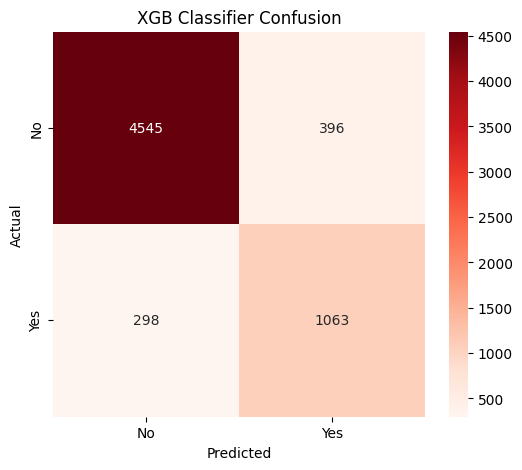

In [17]:
labels = ["No", "Yes"]
plt.figure(figsize=(6,5))
sns.heatmap(xg_confusion, annot=True, fmt='g', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title("XGB Classifier Confusion")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest Classifier

In [18]:
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
])

rf_param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 15],
    'model__min_samples_split': [2, 5, 10]
}

rf_cv = StratifiedKFold(
    n_splits=CV_FOLD, 
    shuffle= True,
    random_state=RANDOM_STATE
)

rf_grid_cv = RandomizedSearchCV(
    estimator= rf_pipeline,
    param_distributions= rf_param_dist,
    scoring='recall',
    cv=rf_cv, n_iter=10,
    verbose=1, n_jobs=-1
)
rf_model = rf_grid_cv.fit(xtrain, ytrain) 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [19]:
rf_result, rf_pred_proba, rf_confusion, rf_roc_auc = evaluate_model(
    model = rf_model,
    xtrain = xtrain,
    xtest= xtest, 
    ytrain=ytrain,
    ytest= ytest,
    model_name = 'Random Forest Classifier'
)
rf_result

Random Forest Classifier - Evaluation Report
____________________
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4941
           1       0.82      0.76      0.79      1361

    accuracy                           0.91      6302
   macro avg       0.88      0.86      0.87      6302
weighted avg       0.91      0.91      0.91      6302

________________________________________


,Model,Train Recall,Test Recall,Accuracay,Recall Score,F1 Score,Roc Auc,Best Score
0,Random Forest Classifier,0.784022,0.764144,0.912726,0.764144,0.790875,0.932702,0.752617


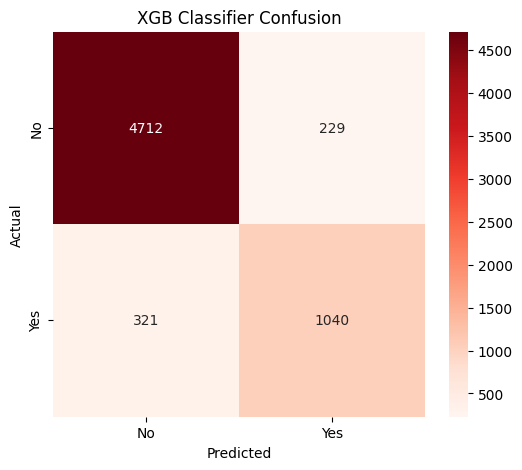

In [20]:
plt.figure(figsize=(6,5))
sns.heatmap(rf_confusion, annot=True, fmt='g', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title("XGB Classifier Confusion")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
comparing = pd.concat([xg_result, rf_result], ignore_index=True)
comparing.sort_values(by='Recall Score', ascending=False)

,Model,Train Recall,Test Recall,Accuracay,Recall Score,F1 Score,Roc Auc,Best Score
0,XGB Classifier,0.772268,0.781043,0.889876,0.781043,0.753901,0.924528,0.770248
1,Random Forest Classifier,0.784022,0.764144,0.912726,0.764144,0.790875,0.932702,0.752617


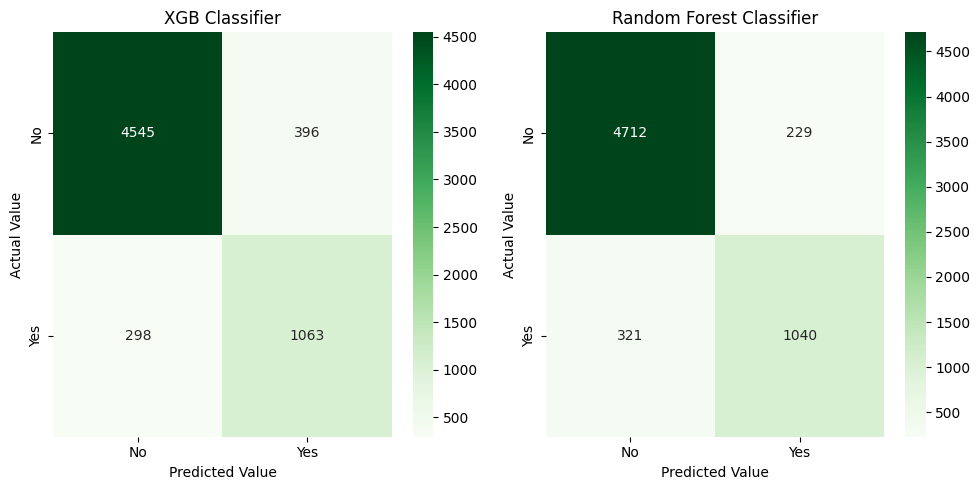

In [22]:
confusion_matrixes = [xg_confusion, rf_confusion]
titles = ['XGB Classifier', 'Random Forest Classifier']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, cm, title, in zip(axes.flatten(), confusion_matrixes, titles):
    sns.heatmap(
        cm, annot=True, fmt='g', cmap='Greens',
        ax=ax, xticklabels=labels, yticklabels=labels
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Value")
    ax.set_ylabel("Actual Value")
plt.tight_layout()
plt.show()


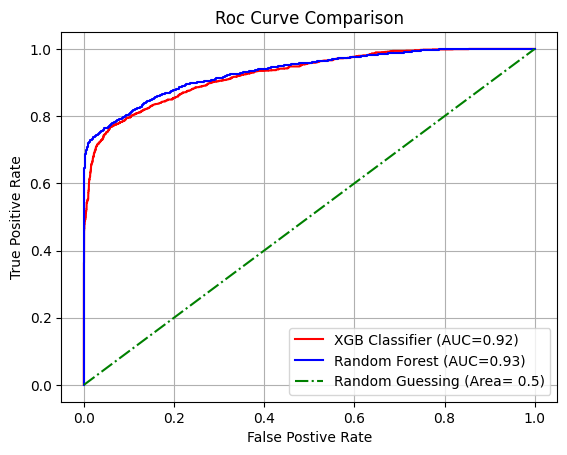

In [23]:
fpr1, tpr1, _ = roc_curve(ytest, xg_pred_proba)
fpr2, tpr2, _ = roc_curve(ytest, rf_pred_proba)

plt.plot(fpr1, tpr1, color='red', label= f"XGB Classifier (AUC={xg_roc_auc:.2f})")
plt.plot(fpr2, tpr2, color='blue', label= f"Random Forest (AUC={rf_roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color='green', linestyle='-.', label="Random Guessing (Area= 0.5)")

plt.title("Roc Curve Comparison")
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')        
plt.grid(True)                     
plt.show() 

# Threshold Tuning

# for XGB Classifier 

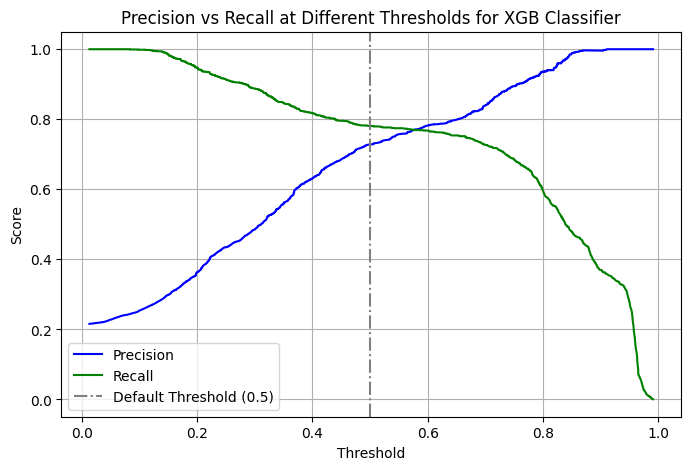

In [31]:

xg_precisions, xg_recalls, xg_thresholds = precision_recall_curve(ytest, xg_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(xg_thresholds, xg_precisions[:-1], label='Precision', color='blue')
plt.plot(xg_thresholds, xg_recalls[:-1], label='Recall', color='green')
plt.axvline(x=0.5, color='gray', linestyle='-.', label= 'Default Threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds for XGB Classifier')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
xg_f1_scores = 2 * (xg_precisions[:-1] * xg_recalls[:-1]) / (xg_precisions[:-1] + xg_recalls[:-1])
xg_optimal_idx = xg_f1_scores.argmax()
xg_optimal_threshold = xg_thresholds[xg_optimal_idx]

print(f"Optimal Threshold : {xg_optimal_threshold:.4f}")
print(f"Precision : {xg_precisions[xg_optimal_idx]:.4f}")
print(f"Recall : {xg_recalls[xg_optimal_idx]:.4f}")
print(f"F1 Score : {xg_f1_scores[xg_optimal_idx]:.4f}")

Optimal Threshold : 0.7197
Precision : 0.8661
Recall : 0.7179
F1 Score : 0.7851


In [37]:
xg_y_pred_tuned = (xg_pred_proba >= xg_optimal_threshold).astype('int')
print(classification_report(ytest, xg_y_pred_tuned))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4941
           1       0.87      0.72      0.79      1361

    accuracy                           0.92      6302
   macro avg       0.90      0.84      0.87      6302
weighted avg       0.91      0.92      0.91      6302



# For Random Forest

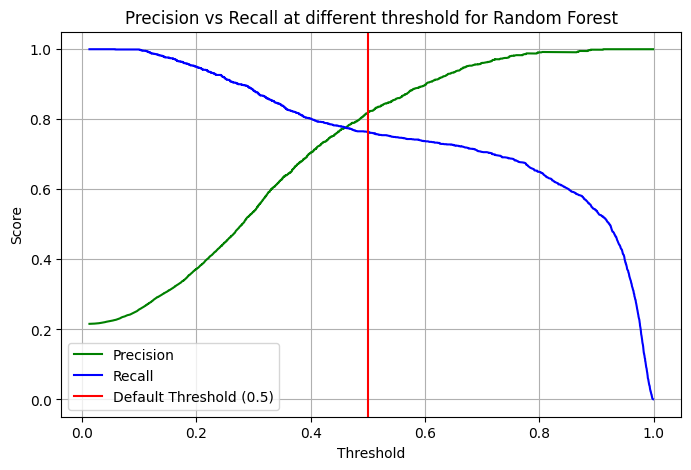

In [35]:
rf_precisions, rf_recalls, rf_thresholds = precision_recall_curve(ytest, rf_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(rf_thresholds, rf_precisions[:-1], label='Precision', color='green')
plt.plot(rf_thresholds, rf_recalls[:-1], label='Recall', color='blue')
plt.axvline(x=0.5, color='red', linestyle='-', label='Default Threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at different threshold for Random Forest')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
rf_f1_scores = 2 * (rf_precisions[:-1] * rf_recalls[:-1]) / (rf_precisions[:-1] + rf_recalls[:-1])
rf_optimal_idx = rf_f1_scores.argmax()
rf_optimal_threshold = rf_thresholds[rf_optimal_idx]

print(f"Optimal Threshold : {rf_optimal_threshold:.4f}")
print(f"Precision         : {rf_precisions[rf_optimal_idx]:.4f}")
print(f"Recall            : {rf_recalls[rf_optimal_idx]:.4f}")
print(f"F1 Score          : {rf_f1_scores[rf_optimal_idx]:.2f}")

Optimal Threshold : 0.6669
Precision         : 0.9479
Recall            : 0.7215
F1 Score          : 0.82


In [39]:
rf_y_pred_tuned = (rf_pred_proba >= rf_optimal_threshold).astype('int')
print(classification_report(ytest, rf_y_pred_tuned))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4941
           1       0.95      0.72      0.82      1361

    accuracy                           0.93      6302
   macro avg       0.94      0.86      0.89      6302
weighted avg       0.93      0.93      0.93      6302



Overall good Random Forest so I Choose Random forest

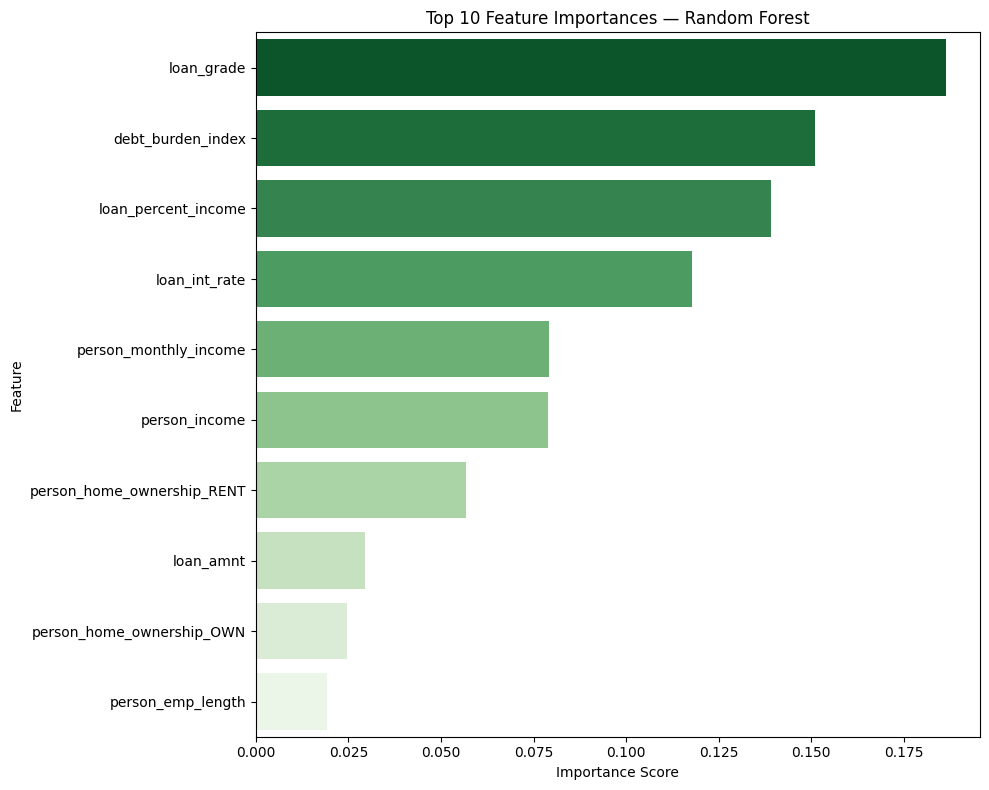

In [42]:
best_rf = rf_model.best_estimator_.named_steps['model']

feature_df = pd.DataFrame({
    'Feature' : x.columns,
    'Importance' : best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data = feature_df.head(10),
    x='Importance',
    y='Feature',
    palette='Greens_r'
)
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [43]:
feature_columns = x.columns.to_list()
feature_columns

['person_age',
 'person_income',
 'person_monthly_income',
 'person_emp_length',
 'emp_stability',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length',
 'person_home_ownership_OTHER',
 'credit_hist_ratio',
 'debt_burden_index',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE']

In [46]:
joblib.dump(best_rf, "../models/rf_model.joblib")
print("Model saved Succesfully")

Model saved Succesfully


In [47]:
joblib.dump(feature_columns, "../models/feature_columns.joblib")
print("Column Saved Succesfully")

Column Saved Succesfully
